# Zuri Watch: Day 2 Extension, Intermediate + Advanced Tracks

**Team:** Zuri Watch (WeThinkCode_) &nbsp;|&nbsp; **Primary track:** 🔴 Advanced &nbsp;|&nbsp; **Also submitted:** 🟡 Intermediate

This is our fully run copy of the CAIRLab Day 2 extension notebook. The organizers' harness,
data pipeline, partitions and `WeakMLP` are unchanged. Our work lives in the two
🔧 YOUR TURN cells plus the analysis sections we added after each one.

| Track | Before | After | Change |
|---|---|---|---|
| 🟡 Intermediate (non-IID, no attack) | naive FedAvg | **Step-normalised, one-bank-one-vote aggregation** | see Section 6 |
| 🔴 Advanced (client 1 scale attack, x15) | naive FedAvg under attack | **Zuri Guard: magnitude quarantine + clipped aggregation** | see Section 7 |

The exact numbers are printed by the cells below and summarised in `results.json`.

**Small changes to the harness, and why:**
1. We reseed torch and numpy immediately before every `run_fl` call (`seeded_run`). The original
   notebook seeds once at the top, so every result depended on how many runs came before it.
   Reseeding makes each before/after pair a fair, reproducible comparison on identical client
   shuffles and the identical initial model.
2. `run_fl` has one new optional argument, `attack_start` (default `0`, which is the original
   behaviour). We only use it in the stress test to simulate a bank that turns malicious partway through.
3. Fixed the `"\\n"` typo in print statements so the output reads cleanly.

Everything else, including `evaluate()`, the 0.5 threshold, and the test set, is exactly as provided.

## 0. Setup

In [1]:
# torch, scikit-learn, pandas, numpy and matplotlib are preinstalled on Kaggle and Colab
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import copy, json, os, hashlib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs("data", exist_ok=True)
print("Setup complete.")

import matplotlib
import matplotlib.pyplot as plt
os.makedirs("figures", exist_ok=True)

Setup complete.


## 1. Load and clean the dataset (same as Day 1)

In [2]:
TRAIN_URL = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt"
TEST_URL  = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt"

COLS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty",
]

train_raw = pd.read_csv(TRAIN_URL, names=COLS)
test_raw  = pd.read_csv(TEST_URL, names=COLS)

def clean(df):
    df = df.drop(columns=["difficulty"]).copy()
    df["binary_label"] = (df["label"] != "normal").astype(int)
    return df

train_df = clean(train_raw)
test_df  = clean(test_raw)

CAT_COLS = ["protocol_type", "service", "flag"]
encoders = {}
for c in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([train_df[c], test_df[c]], axis=0))
    train_df[c] = le.transform(train_df[c])
    test_df[c]  = le.transform(test_df[c])
    encoders[c] = le

FEATURE_COLS = [c for c in train_df.columns if c not in ["label", "binary_label"]]

scaler = StandardScaler()
train_df[FEATURE_COLS] = scaler.fit_transform(train_df[FEATURE_COLS])
test_df[FEATURE_COLS]  = scaler.transform(test_df[FEATURE_COLS])

print("features:", len(FEATURE_COLS))

features: 41


## 2. Partition into 5 clients — IID (for reference) and non-IID (today's data)

Same holdout reservation logic as Day 1 (same seed, so it's the identical reserved rows —
this doesn't matter for today's scoring, it's just kept consistent).

Today you also get a **non-IID** partition: the same pool of training rows, but split so
each "bank" sees a skewed slice of traffic — one might see mostly denial-of-service attacks,
another almost entirely normal traffic. This is realistic (different banks see different
customers and attackers), and it's what breaks naive FedAvg.

In [3]:
N_CLIENTS = 5
HOLDOUT_SIZE = 15000

_rng = np.random.RandomState(SEED)
_perm = _rng.permutation(len(train_df))
_holdout_idx = _perm[:HOLDOUT_SIZE]
_pool_idx = _perm[HOLDOUT_SIZE:]
train_pool = train_df.iloc[_pool_idx].reset_index(drop=True)

def make_iid_partition(df, n_clients=N_CLIENTS, seed=SEED):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(df))
    chunks = np.array_split(idx, n_clients)
    return [df.iloc[c].reset_index(drop=True) for c in chunks]

FAMILY_MAP = {
    "normal": "normal",
    "neptune": "dos", "back": "dos", "land": "dos", "pod": "dos", "smurf": "dos",
    "teardrop": "dos", "apache2": "dos", "udpstorm": "dos", "processtable": "dos",
    "worm": "dos", "mailbomb": "dos",
    "satan": "probe", "ipsweep": "probe", "nmap": "probe", "portsweep": "probe",
    "mscan": "probe", "saint": "probe",
}

def make_noniid_partition(df, n_clients=N_CLIENTS, alpha=0.3, seed=SEED):
    '''Dirichlet-skewed split by attack family. Low alpha = strong skew.'''
    rng = np.random.RandomState(seed)
    df = df.copy()
    df["family"] = df["label"].map(lambda x: FAMILY_MAP.get(x, "r2l_u2r_other"))
    client_indices = [[] for _ in range(n_clients)]
    for fam in df["family"].unique():
        fam_idx = df.index[df["family"] == fam].to_numpy().copy()
        rng.shuffle(fam_idx)
        proportions = rng.dirichlet(alpha=[alpha] * n_clients)
        split_points = (np.cumsum(proportions) * len(fam_idx)).astype(int)[:-1]
        for i, s in enumerate(np.split(fam_idx, split_points)):
            client_indices[i].extend(s.tolist())
    out = []
    for ci in client_indices:
        rng.shuffle(ci)
        out.append(df.loc[ci].drop(columns=["family"]).reset_index(drop=True))
    return out

iid_clients = make_iid_partition(train_pool)
noniid_clients = make_noniid_partition(train_pool)

print("IID sizes:", [len(c) for c in iid_clients])
print("\nNon-IID sizes:", [len(c) for c in noniid_clients])
for i, c in enumerate(noniid_clients):
    print(f"  client {i} label mix:", c["binary_label"].value_counts(normalize=True).round(2).to_dict())

IID sizes: [22195, 22195, 22195, 22194, 22194]

Non-IID sizes: [6272, 10658, 48219, 23239, 22585]
  client 0 label mix: {1: 0.81, 0: 0.19}
  client 1 label mix: {1: 0.86, 0: 0.14}
  client 2 label mix: {1: 0.68, 0: 0.32}
  client 3 label mix: {0: 0.85, 1: 0.15}
  client 4 label mix: {0: 0.96, 1: 0.04}


## 3. The weak baseline model (same as Day 1)

In [4]:
N_FEATURES = len(FEATURE_COLS)

class WeakMLP(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

## 4. The FL harness — extended with robust aggregation and attack simulation

Same local training and FedAvg as Day 1, plus what today's tracks need: a
`coordinate_median` robust-aggregation baseline, a `custom` aggregation hook, and the
ability to simulate malicious clients.

In [5]:
X_test = torch.tensor(test_df[FEATURE_COLS].values, dtype=torch.float32)
y_test = torch.tensor(test_df["binary_label"].values, dtype=torch.float32)

def df_to_tensors(df):
    X = torch.tensor(df[FEATURE_COLS].values, dtype=torch.float32)
    y = torch.tensor(df["binary_label"].values, dtype=torch.float32)
    return X, y

def local_train(model, X, y, epochs=1, lr=0.05, batch_size=256):
    model = copy.deepcopy(model)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    n = len(X)
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X[idx]), y[idx])
            loss.backward()
            opt.step()
    return model

def get_flat_params(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

def set_flat_params(model, flat):
    i = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(flat[i:i + n].view(p.shape))
        i += n

def fedavg(models, weights):
    weights = np.array(weights, dtype=float) / np.sum(weights)
    flats = torch.stack([get_flat_params(m) for m in models])
    avg = (flats * torch.tensor(weights, dtype=torch.float32).unsqueeze(1)).sum(dim=0)
    out = copy.deepcopy(models[0])
    set_flat_params(out, avg)
    return out

def coordinate_median(models):
    '''A simple robust-aggregation baseline: take the per-coordinate median of all
    client updates instead of the (weighted) mean. Outliers (e.g. a poisoned update
    with an inflated magnitude) influence the median far less than the mean.'''
    flats = torch.stack([get_flat_params(m) for m in models])
    med = flats.median(dim=0).values
    out = copy.deepcopy(models[0])
    set_flat_params(out, med)
    return out

def evaluate(model):
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_test)) > 0.5).float()
    return {
        "precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "recall": round(recall_score(y_test, preds, zero_division=0), 4),
        "f1": round(f1_score(y_test, preds, zero_division=0), 4),
    }

def run_fl(client_dfs, model_fn=lambda: WeakMLP(), rounds=8, epochs=1,
           aggregation="fedavg", agg_fn=None,
           malicious_clients=None, attack="scale", scale_factor=15.0, verbose=True,
           attack_start=0):
    '''
    aggregation: "fedavg" | "median" | "custom" (use agg_fn for "custom")
    malicious_clients: list of client indices that send poisoned updates (advanced track)
    attack: "label_flip" or "scale" (scale = label_flip + inflated update magnitude)
    attack_start: round index where the malicious clients switch on (0 = from the start, as originally)
    '''
    malicious_clients = malicious_clients or []
    global_model = model_fn()
    client_tensors = [df_to_tensors(df) for df in client_dfs]

    history = []
    for r in range(rounds):
        local_models, sizes = [], []
        global_flat = get_flat_params(global_model)

        for cid, (X, y) in enumerate(client_tensors):
            is_malicious = cid in malicious_clients and r >= attack_start
            if is_malicious:
                y = 1 - y  # label-flip
            lm = local_train(global_model, X, y, epochs=epochs)
            if is_malicious and attack == "scale":
                delta = get_flat_params(lm) - global_flat
                set_flat_params(lm, global_flat + scale_factor * delta)
            local_models.append(lm)
            sizes.append(len(X))

        prev_global_model = global_model
        if aggregation == "fedavg":
            global_model = fedavg(local_models, sizes)
        elif aggregation == "median":
            global_model = coordinate_median(local_models)
        elif aggregation == "custom":
            global_model = agg_fn(local_models, sizes, prev_global_model)
        else:
            raise ValueError(f"unknown aggregation: {aggregation}")

        metrics = evaluate(global_model)
        history.append(metrics)
        if verbose:
            print(f"round {r+1:>2}: {metrics}")

    return global_model, history


# Added by Zuri Watch: reseed right before each run so every comparison starts from the
# same initial model and the same client shuffles, no matter what ran before it.
def seeded_run(client_dfs, seed=SEED, **kwargs):
    torch.manual_seed(seed)
    np.random.seed(seed)
    return run_fl(client_dfs, **kwargs)

# Small helpers our aggregators share
def model_from_flat(flat, like):
    out = copy.deepcopy(like)
    set_flat_params(out, flat)
    return out

def local_steps(sizes, batch_size=256):
    # how many SGD steps each bank took this round (the server knows this from the sizes)
    return np.ceil(np.asarray(sizes, dtype=float) / batch_size)

## 5. Recompute your Day 1 reference point

Quick reference run on IID data — same as your Day 1 baseline — so you have a same-session
number to compare today's non-IID results against.

In [6]:
print("Reference: weak model, IID clients, naive FedAvg")
baseline_model, baseline_history = seeded_run(iid_clients, rounds=6)
print("\nFinal:", baseline_history[-1])

Reference: weak model, IID clients, naive FedAvg


round  1: {'precision': 0.9574, 'recall': 0.2875, 'f1': 0.4423}


round  2: {'precision': 0.9695, 'recall': 0.6026, 'f1': 0.7432}


round  3: {'precision': 0.9694, 'recall': 0.628, 'f1': 0.7622}
round  4: {'precision': 0.9315, 'recall': 0.6348, 'f1': 0.7551}


round  5: {'precision': 0.9324, 'recall': 0.6413, 'f1': 0.7599}


round  6: {'precision': 0.9324, 'recall': 0.6473, 'f1': 0.7641}

Final: {'precision': 0.9324, 'recall': 0.6473, 'f1': 0.7641}


---
## 🟡 Intermediate track — fix the non-IID aggregation

Switch to the skewed client split and watch what happens with plain FedAvg.

In [7]:
print("Non-IID clients, naive FedAvg (same model, same aggregation as baseline)")
noniid_model, noniid_history = seeded_run(noniid_clients, rounds=8)
print("\nIID F1:    ", baseline_history[-1]["f1"])
print("Non-IID F1:", noniid_history[-1]["f1"])

Non-IID clients, naive FedAvg (same model, same aggregation as baseline)


round  1: {'precision': 0.9858, 'recall': 0.2063, 'f1': 0.3412}
round  2: {'precision': 0.9863, 'recall': 0.5166, 'f1': 0.678}


round  3: {'precision': 0.9436, 'recall': 0.5359, 'f1': 0.6836}
round  4: {'precision': 0.9374, 'recall': 0.5484, 'f1': 0.692}


round  5: {'precision': 0.9371, 'recall': 0.5554, 'f1': 0.6974}
round  6: {'precision': 0.9383, 'recall': 0.5625, 'f1': 0.7034}


round  7: {'precision': 0.9408, 'recall': 0.5662, 'f1': 0.7069}


round  8: {'precision': 0.9524, 'recall': 0.5681, 'f1': 0.7117}

IID F1:     0.7641
Non-IID F1: 0.7117


Naive FedAvg treats every client's update as equally trustworthy and just weights by
data size. When one client's local distribution is very different from the global
distribution (e.g. almost-all-attack-traffic), its update can pull the global model in a
direction that hurts everyone else.

**Ideas to improve aggregation**, roughly in order of effort:
- Weight clients differently — e.g. down-weight clients whose local class distribution is
  most different from the (estimated) global distribution.
- **FedProx-style**: add a proximal penalty term in local training that keeps each client's
  local model from drifting too far from the current global model.
- Cluster clients by similarity of their updates and aggregate within clusters before a
  final merge.

**Your hook:** write a function with signature
`agg_fn(local_models, sizes, prev_global_model) -> model` and pass it to
`run_fl(..., aggregation="custom", agg_fn=my_agg_fn)`.

### Our diagnosis before writing any code

Look at the partition printout in Section 2. The banks differ in two ways, not one:

* **Label mix:** banks 0 to 2 are 68 to 86% attack traffic, banks 3 and 4 are 85 to 96% normal.
* **Size:** bank 2 holds 48k rows, bank 0 only 6k. With a fixed batch size of 256 and one local
  epoch, bank 2 takes **189 SGD steps** per round while bank 0 takes **25**.

Naive FedAvg then weights bank 2 by its size (about 43% of the vote) *and* bank 2's update is
already the longest, because it walked 7x more steps towards its own local optimum. The two
effects multiply, so the global model mostly becomes "bank 2's model". This is the
*objective inconsistency* problem described in FedNova (Wang et al., 2020): with unequal local
step counts, FedAvg converges to the optimum of a skewed, implicitly reweighted objective.

We first tried the notebook's first suggestion, re-weighting banks so the pooled label mix is
balanced (row "label-balanced weights" in the Section 6 table). It barely moves F1, because the pool as
a whole is already close to 50/50. So label balance is not what breaks FedAvg here. Step count and
size dominance are.

### Our aggregation: step-normalised, one bank one vote

1. **Normalise each update by its number of local steps**, so every bank contributes a
   *per-step direction* instead of a distance that grows with its dataset size.
2. **Average those directions with equal weight per bank.** Each bank gets one vote. Minority
   traffic patterns that live only in small banks are no longer drowned out.
3. **Rescale** by the average step count so the global model still moves a normal FedAvg-sized
   step each round.

There is also a security reason for equal weights, which matters for the Advanced track: in
FedAvg the weight comes from `sizes`, a number each bank *reports about itself*. A malicious bank can
simply claim to hold a million rows. One bank one vote removes that lever.

In [8]:
# 🔧 YOUR TURN — intermediate track
# Step-normalised aggregation (FedNova style) with one vote per bank.

def my_agg_fn(local_models, sizes, prev_global_model):
    global_flat = get_flat_params(prev_global_model)
    steps = local_steps(sizes)

    # each bank's update divided by how many SGD steps it took, so size stops inflating it
    per_step = torch.stack([
        (get_flat_params(m) - global_flat) / s for m, s in zip(local_models, steps)
    ])

    # every bank gets the same vote, then we scale back up to a normal sized global step
    weights = np.ones(len(local_models)) / len(local_models)
    avg_direction = (per_step * torch.tensor(weights, dtype=torch.float32).unsqueeze(1)).sum(dim=0)
    effective_steps = float((weights * steps).sum())

    return model_from_flat(global_flat + effective_steps * avg_direction, local_models[0])

custom_model, custom_history = seeded_run(noniid_clients, rounds=8, aggregation="custom", agg_fn=my_agg_fn)
print("\nNaive non-IID F1:", noniid_history[-1]["f1"])
print("Your aggregation F1:", custom_history[-1]["f1"])

round  1: {'precision': 0.9625, 'recall': 0.6655, 'f1': 0.7869}


round  2: {'precision': 0.925, 'recall': 0.6757, 'f1': 0.7809}


round  3: {'precision': 0.9234, 'recall': 0.6891, 'f1': 0.7892}


round  4: {'precision': 0.9217, 'recall': 0.686, 'f1': 0.7866}


round  5: {'precision': 0.9199, 'recall': 0.6836, 'f1': 0.7844}


round  6: {'precision': 0.9182, 'recall': 0.6823, 'f1': 0.7829}


round  7: {'precision': 0.9177, 'recall': 0.6823, 'f1': 0.7827}


round  8: {'precision': 0.9173, 'recall': 0.6816, 'f1': 0.7821}

Naive non-IID F1: 0.7117
Your aggregation F1: 0.7821


### 6. Intermediate results: is it real, and why does it work?

A single run can be lucky, so we repeat every method over **5 seeds** (0 to 4). We also run an
**ablation**: each of the two ideas on its own, to show both are needed. The last row shows that
on the IID split our method is *identical* to FedAvg (every bank has the same size, so there is
nothing to correct). That shows the gain comes from handling heterogeneity, not from a hidden
change such as a larger learning rate.

In [9]:
def size_weighted_fedavg_custom(local_models, sizes, prev_global_model):
    # plain FedAvg written as a custom fn, so the ablation table uses the same code path
    return fedavg(local_models, sizes)

def equal_weights_only(local_models, sizes, prev_global_model):
    return fedavg(local_models, [1] * len(local_models))

def step_norm_size_weighted(local_models, sizes, prev_global_model):
    g = get_flat_params(prev_global_model)
    steps = local_steps(sizes)
    w = np.asarray(sizes, float); w /= w.sum()
    per_step = torch.stack([(get_flat_params(m) - g) / s for m, s in zip(local_models, steps)])
    d = (per_step * torch.tensor(w, dtype=torch.float32).unsqueeze(1)).sum(0)
    return model_from_flat(g + float((w * steps).sum()) * d, local_models[0])

def label_balanced_weights(local_models, sizes, prev_global_model):
    # the notebook's first suggestion: tilt the size weights so the pooled label mix is 50/50.
    # Each bank shares only its attack rate (one number), never rows.
    rates = np.array([c["binary_label"].mean() for c in noniid_clients])
    n = np.asarray(sizes, float)
    lo, hi = -50.0, 50.0
    for _ in range(100):  # bisection on the tilt strength
        lam = (lo + hi) / 2
        w = n * np.exp(lam * (rates - 0.5)); w /= w.sum()
        lo, hi = (lam, hi) if (w * rates).sum() < 0.5 else (lo, lam)
    return fedavg(local_models, w)

SEEDS = [0, 1, 2, 3, 4]

def multi_seed(client_dfs, seeds=SEEDS, **kwargs):
    rows = []
    for s in seeds:
        m, h = seeded_run(client_dfs, seed=s, rounds=8, verbose=False, **kwargs)
        rows.append(evaluate(m))
    f1s = np.array([r["f1"] for r in rows])
    return {"f1_mean": round(float(f1s.mean()), 4), "f1_std": round(float(f1s.std()), 4),
            "precision_mean": round(float(np.mean([r["precision"] for r in rows])), 4),
            "recall_mean": round(float(np.mean([r["recall"] for r in rows])), 4),
            "f1_per_seed": f1s.tolist()}

ablation = {
    "IID reference, FedAvg":                        multi_seed(iid_clients),
    "Non-IID, naive FedAvg (before)":               multi_seed(noniid_clients),
    "Non-IID, label-balanced weights":              multi_seed(noniid_clients, aggregation="custom", agg_fn=label_balanced_weights),
    "Non-IID, equal weights only":                  multi_seed(noniid_clients, aggregation="custom", agg_fn=equal_weights_only),
    "Non-IID, step-normalised only":                multi_seed(noniid_clients, aggregation="custom", agg_fn=step_norm_size_weighted),
    "Non-IID, ours: step-norm + one vote (after)":  multi_seed(noniid_clients, aggregation="custom", agg_fn=my_agg_fn),
    "IID, ours (sanity check, should equal FedAvg)": multi_seed(iid_clients, aggregation="custom", agg_fn=my_agg_fn),
}
ablation_df = pd.DataFrame(ablation).T[["f1_mean", "f1_std", "precision_mean", "recall_mean"]]
display(ablation_df)

,f1_mean,f1_std,precision_mean,recall_mean
"IID reference, FedAvg",0.7556,0.0064,0.9367,0.6335
"Non-IID, naive FedAvg (before)",0.7147,0.0086,0.9512,0.5725
"Non-IID, label-balanced weights",0.718,0.0078,0.9495,0.5774
"Non-IID, equal weights only",0.7491,0.0128,0.9292,0.6277
"Non-IID, step-normalised only",0.7476,0.0159,0.9298,0.6254
"Non-IID, ours: step-norm + one vote (after)",0.7787,0.0082,0.9183,0.676
"IID, ours (sanity check, should equal FedAvg)",0.7556,0.0064,0.9367,0.6335


**Where does the extra F1 come from?** Recall rises a lot while precision drops a little: the model
catches far more attacks at the cost of some extra false alarms on normal traffic (see the last row below). The next cell breaks recall down by attack family
on the held-out test set. The NSL-KDD test file deliberately contains attack types that never appear
in training, so the families that grow most show what generalises.

In [10]:
def family_of(label):
    return FAMILY_MAP.get(label, "r2l_u2r_other")

test_family = test_df["label"].map(family_of).values

def recall_by_family(model):
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_test)) > 0.5).numpy()
    out = {}
    for fam in ["dos", "probe", "r2l_u2r_other"]:
        mask = test_family == fam
        out[fam] = round(float(preds[mask].mean()), 3)
    out["normal (false alarm rate)"] = round(float(preds[test_family == "normal"].mean()), 3)
    return out

family_df = pd.DataFrame({
    "naive FedAvg": recall_by_family(noniid_model),
    "ours": recall_by_family(custom_model),
})
display(family_df)

,naive FedAvg,ours
dos,0.779,0.785
probe,0.582,0.967
r2l_u2r_other,0.025,0.187
normal (false alarm rate),0.037,0.081


---
## 🔴 Advanced track (optional) — detect or resist a poisoning attack

Partway through, imagine one of your five "banks" has been compromised (or is actively
malicious) and starts sending sabotaged updates instead of honest ones. Below, client `1`
is malicious: it flips its local labels **and** inflates the magnitude of its update so it
dominates a plain average, regardless of how much data it actually has.

In [11]:
print("Non-IID + 1 malicious client (scale attack), naive FedAvg — should degrade")
attacked_model, attacked_history = seeded_run(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
)
print("\nClean non-IID F1:  ", noniid_history[-1]["f1"])
print("Under attack F1:    ", attacked_history[-1]["f1"])

Non-IID + 1 malicious client (scale attack), naive FedAvg — should degrade
round  1: {'precision': 1.0, 'recall': 0.1038, 'f1': 0.1881}


round  2: {'precision': 0.9959, 'recall': 0.1128, 'f1': 0.2026}
round  3: {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


round  4: {'precision': 0.8421, 'recall': 0.0087, 'f1': 0.0173}
round  5: {'precision': 0.8779, 'recall': 0.0118, 'f1': 0.0232}


round  6: {'precision': 0.854, 'recall': 0.0337, 'f1': 0.0649}
round  7: {'precision': 0.9868, 'recall': 0.2497, 'f1': 0.3986}


round  8: {'precision': 0.0794, 'recall': 0.0376, 'f1': 0.0511}

Clean non-IID F1:   0.7117
Under attack F1:     0.0511


In [12]:
print("Same attack, but aggregating with the coordinate-median baseline defense")
defended_model, defended_history = seeded_run(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
    aggregation="median",
)
print("\nUnder attack (naive FedAvg): ", attacked_history[-1]["f1"])
print("Under attack (median defense):", defended_history[-1]["f1"])

Same attack, but aggregating with the coordinate-median baseline defense
round  1: {'precision': 1.0, 'recall': 0.082, 'f1': 0.1515}


round  2: {'precision': 0.999, 'recall': 0.1514, 'f1': 0.263}
round  3: {'precision': 0.9991, 'recall': 0.4551, 'f1': 0.6253}


round  4: {'precision': 0.9953, 'recall': 0.4952, 'f1': 0.6614}
round  5: {'precision': 0.9884, 'recall': 0.5102, 'f1': 0.673}


round  6: {'precision': 0.988, 'recall': 0.5186, 'f1': 0.6802}
round  7: {'precision': 0.9878, 'recall': 0.5227, 'f1': 0.6837}


round  8: {'precision': 0.9875, 'recall': 0.525, 'f1': 0.6855}

Under attack (naive FedAvg):  0.0511
Under attack (median defense): 0.6855


`coordinate_median` is given as a working baseline defense — notice it already recovers
some of the lost F1. That's your floor, not your ceiling. Try cranking `scale_factor` up
(e.g. 30–50) and/or adding a second malicious client (`malicious_clients=[1, 3]`) — at some
point naive FedAvg collapses to F1 ≈ 0. Then push the defense further:

- **Trimmed mean** — drop the top/bottom k updates per coordinate before averaging.
- **Norm clipping** — clip each client's update to a maximum L2 norm before aggregating.
- **Anomaly scoring / Krum-style selection** — score each client's update by similarity to
  the others, and aggregate only the most mutually-consistent subset.
- **Detection, not just robustness** — can you flag *which* client(s) are malicious?

**Your hook:** same as the intermediate track — write
`agg_fn(local_models, sizes, prev_global_model) -> model` and pass `aggregation="custom"`.

### What we learned before building the defense (including what did not work)

**Attempt 1 (side experiment, not kept in this notebook): cosine-similarity trust (FLTrust / Krum flavour).** We scored each bank by how well its
update pointed in the same direction as the coordinate-wise median update, and kept a reputation
across rounds. Over 3 seeds it recovered F1 to about 0.69, no better than the median baseline. It also raised
**false alarms on a clean run**: late in training, the *honest* attack-heavy banks (0 and 1) point
*away* from the median, because they pull the model towards "attack" while the normal-heavy banks
pull towards "normal". Under non-IID data, an honest bank with an unusual customer base
looks almost the same as a label-flipping attacker by direction alone. Banning it would silence the
very minority traffic the Intermediate track taught us to protect.

**What does separate them is magnitude.** On clean runs across 5 seeds, no honest bank's raw update
was ever more than about **1.7x** the median bank's update (measured in the next cell). The scale attack sends about 10 to 15x. So we
detect on magnitude, which is robust to non-IID, and we use clipping as the safety net for anything
subtler.

### Zuri Guard

Each round:
1. **Measure** each bank's raw update size relative to the median bank (the median stays honest
   as long as fewer than half the banks are malicious).
2. **Accumulate suspicion**: suspicion grows by `log2(ratio / 2.5)` whenever a bank's ratio is above
   2.5x (which gives a margin over the 1.72x honest maximum we measured). A 15x update pays about 2.6 in one round. A bank
   hovering just above the line needs several rounds.
3. **Quarantine** is sticky: once suspicion passes 1.0, the bank is excluded for the rest of
   training. A compromised bank does not get to "behave" for a round and slip back in. Every
   quarantine is logged per round, which gives the operators a detection report and an audit trail.
4. **Aggregate the rest** with our Intermediate method (step-normalised, one bank one vote), after
   **clipping** each per-step update to 3x the median of the trusted banks. Clipping limits an attacker
   who stays under the detection threshold, so the most a hidden attacker can do is a
   small, bounded push.

In [13]:
# Where the 2.5x threshold comes from: on clean runs (no attacker), how large does an honest
# bank's raw update get compared to the median bank?
honest_ratios = []

def measure_ratios(local_models, sizes, prev_global_model):
    g = get_flat_params(prev_global_model)
    norms = np.array([(get_flat_params(m) - g).norm().item() for m in local_models])
    honest_ratios.append(norms / np.median(norms))
    return my_agg_fn(local_models, sizes, prev_global_model)

for s in SEEDS:
    seeded_run(noniid_clients, seed=s, rounds=8, verbose=False, aggregation="custom", agg_fn=measure_ratios)
honest_ratios = np.array(honest_ratios)
print("largest honest ratio per bank over 5 clean runs:", honest_ratios.max(axis=0).round(2))
print("overall largest:", honest_ratios.max().round(2), " so a 2.5x threshold leaves a safety margin")

largest honest ratio per bank over 5 clean runs: [0.55 0.82 1.72 1.19 1.21]
overall largest: 1.72  so a 2.5x threshold leaves a safety margin


In [14]:
# 🔧 YOUR TURN — advanced track
# Zuri Guard: magnitude-based detection with sticky quarantine, then clipped,
# step-normalised, one-vote-per-bank aggregation over the banks we still trust.

def make_zuri_guard(ratio_flag=2.5, suspicion_budget=1.0, clip_k=3.0, log=None):
    state = {"suspicion": None, "quarantined": None, "round": 0}

    def zuri_guard(local_models, sizes, prev_global_model):
        n = len(local_models)
        global_flat = get_flat_params(prev_global_model)
        steps = local_steps(sizes)
        updates = torch.stack([get_flat_params(m) - global_flat for m in local_models])

        # 1. how big is each bank's update compared to the median bank?
        raw_norms = updates.norm(dim=1).numpy()
        ratio = raw_norms / np.median(raw_norms)

        # 2 and 3. suspicion builds up above the threshold, and quarantine never resets
        if state["suspicion"] is None:
            state["suspicion"] = np.zeros(n)
            state["quarantined"] = np.zeros(n, dtype=bool)
        state["suspicion"] += np.maximum(0.0, np.log2(ratio / ratio_flag))
        state["quarantined"] |= state["suspicion"] > suspicion_budget
        trusted = ~state["quarantined"]
        if not trusted.any():
            trusted[:] = True  # never aggregate an empty set

        # 4. per-step updates, clipped to a few times the typical trusted bank
        per_step = updates / torch.tensor(steps, dtype=torch.float32).unsqueeze(1)
        per_step_norm = per_step.norm(dim=1)
        cap = clip_k * per_step_norm[torch.tensor(trusted)].median()
        per_step = per_step * torch.clamp(cap / (per_step_norm + 1e-12), max=1.0).unsqueeze(1)

        weights = trusted.astype(float) / trusted.sum()
        direction = (per_step * torch.tensor(weights, dtype=torch.float32).unsqueeze(1)).sum(dim=0)
        effective_steps = float((weights * steps).sum())

        state["round"] += 1
        if log is not None:
            log.append({"round": state["round"],
                        "norm_ratio": np.round(ratio, 2).tolist(),
                        "suspicion": np.round(state["suspicion"], 2).tolist(),
                        "quarantined": [int(i) for i in np.where(state["quarantined"])[0]]})
        return model_from_flat(global_flat + effective_steps * direction, local_models[0])

    return zuri_guard

guard_log = []
my_defense_fn = make_zuri_guard(log=guard_log)

my_defense_model, my_defense_history = seeded_run(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
    aggregation="custom", agg_fn=my_defense_fn,
)
print("\nNaive under attack:    ", attacked_history[-1]["f1"])
print("Median defense:         ", defended_history[-1]["f1"])
print("Your defense:            ", my_defense_history[-1]["f1"])

print("\nDetection log (norm ratio vs median bank, cumulative suspicion, quarantined banks):")
for entry in guard_log:
    print(entry)

round  1: {'precision': 0.9548, 'recall': 0.2552, 'f1': 0.4028}


round  2: {'precision': 0.9677, 'recall': 0.6279, 'f1': 0.7616}


round  3: {'precision': 0.9575, 'recall': 0.6503, 'f1': 0.7745}


round  4: {'precision': 0.9276, 'recall': 0.6648, 'f1': 0.7745}


round  5: {'precision': 0.9268, 'recall': 0.6734, 'f1': 0.78}


round  6: {'precision': 0.9255, 'recall': 0.6717, 'f1': 0.7784}


round  7: {'precision': 0.9249, 'recall': 0.6694, 'f1': 0.7767}


round  8: {'precision': 0.925, 'recall': 0.6684, 'f1': 0.776}

Naive under attack:     0.0511
Median defense:          0.6855
Your defense:             0.776

Detection log (norm ratio vs median bank, cumulative suspicion, quarantined banks):
{'round': 1, 'norm_ratio': [0.46000000834465027, 8.720000267028809, 1.409999966621399, 1.0, 0.9399999976158142], 'suspicion': [0.0, 1.8, 0.0, 0.0, 0.0], 'quarantined': [1]}
{'round': 2, 'norm_ratio': [0.6700000166893005, 17.780000686645508, 1.4199999570846558, 1.0, 0.9599999785423279], 'suspicion': [0.0, 4.63, 0.0, 0.0, 0.0], 'quarantined': [1]}
{'round': 3, 'norm_ratio': [0.7300000190734863, 34.65999984741211, 1.309999942779541, 1.0, 0.9700000286102295], 'suspicion': [0.0, 8.43, 0.0, 0.0, 0.0], 'quarantined': [1]}
{'round': 4, 'norm_ratio': [0.6200000047683716, 47.31999969482422, 1.1299999952316284, 1.0, 1.0], 'suspicion': [0.0, 12.67, 0.0, 0.0, 0.0], 'quarantined': [1]}
{'round': 5, 'norm_ratio': [0.6700000166893005, 52.29999923706055, 1.0599999

### 7. Advanced results: does the defense hold beyond the one scenario it was built for?

A defense that only works against the exact attack it was tuned on is not worth much, so we run
a stress test over **5 seeds**, comparing against FedAvg, the coordinate-median baseline and
Multi-Krum (Blanchard et al., 2017):

* **clean**: no attack. What does the defense cost when nobody is attacking?
* **scale x3**: an *adaptive* attacker that keeps its update small to stay under the detector.
* **scale x50**: a much louder attacker.
* **label flip only**: no scaling at all. This is the hardest case for magnitude detection.
* **attacker is bank 2 / bank 4**: the biggest bank, and the almost-all-normal bank.
* **two attackers (banks 1 and 3)**: 40% of the consortium compromised.
* **partway through**: bank 1 behaves honestly for 3 rounds, then attacks.

We also report an **oracle**: our Intermediate aggregation trained with bank 1 simply removed. This is
the best any detect-and-exclude defense can do, so it shows how much room is left.

Each defense gets a fresh state for every run (`make_zuri_guard()` is called per run).

In [15]:
def multi_krum(local_models, sizes, prev_global_model, f=1, m=3):
    flats = torch.stack([get_flat_params(x) for x in local_models])
    n = len(local_models)
    d = torch.cdist(flats, flats) ** 2
    scores = torch.stack([d[i].sort().values[1:n - f - 1].sum() for i in range(n)])
    chosen = scores.argsort()[:m]
    return model_from_flat(flats[chosen].mean(0), local_models[0])

SCENARIOS = {
    "clean (no attack)":        dict(),
    "scale x15, bank 1 (official)": dict(malicious_clients=[1], attack="scale", scale_factor=15.0),
    "scale x3, bank 1 (stealthy)":  dict(malicious_clients=[1], attack="scale", scale_factor=3.0),
    "scale x50, bank 1":         dict(malicious_clients=[1], attack="scale", scale_factor=50.0),
    "label flip only, bank 1":   dict(malicious_clients=[1], attack="label_flip"),
    "scale x15, bank 2 (largest)": dict(malicious_clients=[2], attack="scale", scale_factor=15.0),
    "scale x15, bank 4":         dict(malicious_clients=[4], attack="scale", scale_factor=15.0),
    "scale x15, banks 1 and 3":  dict(malicious_clients=[1, 3], attack="scale", scale_factor=15.0),
    "scale x15, bank 1 from round 4": dict(malicious_clients=[1], attack="scale", scale_factor=15.0, attack_start=3),
}
DEFENSES = {
    "FedAvg":        lambda: dict(),
    "Coord. median": lambda: dict(aggregation="median"),
    "Multi-Krum":    lambda: dict(aggregation="custom", agg_fn=multi_krum),
    "Ours: Intermediate agg only": lambda: dict(aggregation="custom", agg_fn=my_agg_fn),
    "Ours: Zuri Guard": lambda: dict(aggregation="custom", agg_fn=make_zuri_guard()),
}

def multi_seed_fresh(client_dfs, scenario, defense_factory, seeds=SEEDS):
    f1s = []
    for s in seeds:
        m, _ = seeded_run(client_dfs, seed=s, rounds=8, verbose=False, **scenario, **defense_factory())
        f1s.append(evaluate(m)["f1"])
    return float(np.mean(f1s)), float(np.std(f1s))

stress = {}
for sname, scen in SCENARIOS.items():
    stress[sname] = {}
    for dname, fac in DEFENSES.items():
        mean, std = multi_seed_fresh(noniid_clients, scen, fac)
        stress[sname][dname] = round(mean, 4)
    print(f"done: {sname}")

stress_df = pd.DataFrame(stress).T
display(stress_df)

honest_only = [c for i, c in enumerate(noniid_clients) if i != 1]
oracle = multi_seed(honest_only, aggregation="custom", agg_fn=my_agg_fn)
print("Oracle (bank 1 removed by hand, Intermediate aggregation):", oracle["f1_mean"])

done: clean (no attack)


done: scale x15, bank 1 (official)


done: scale x3, bank 1 (stealthy)


done: scale x50, bank 1


done: label flip only, bank 1


...

done: scale x15, bank 4


done: scale x15, banks 1 and 3


done: scale x15, bank 1 from round 4


,FedAvg,Coord. median,Multi-Krum,Ours: Intermediate agg only,Ours: Zuri Guard
clean (no attack),0.7147,0.7288,0.7198,0.7787,0.7787
"scale x15, bank 1 (official)",0.2461,0.6804,0.6973,0.2241,0.7639
"scale x3, bank 1 (stealthy)",0.6589,0.6784,0.6973,0.6489,0.7617
"scale x50, bank 1",0.5331,0.6803,0.6973,0.5648,0.7639
"label flip only, bank 1",0.6878,0.6771,0.7081,0.6924,0.7215
"scale x15, bank 2 (largest)",0.5147,0.7760,0.7192,0.8039,0.7828
"scale x15, bank 4",0.6765,0.8003,0.7885,0.7028,0.7912
"scale x15, banks 1 and 3",0.1976,0.7458,0.7359,0.4973,0.7740
"scale x15, bank 1 from round 4",0.1721,0.6958,0.7115,0.2171,0.7642


Oracle (bank 1 removed by hand, Intermediate aggregation): 0.7636


In [16]:
# Detection quality: over every attacked scenario and seed, did Zuri Guard quarantine the right banks?
detect_rows = []
for sname, scen in SCENARIOS.items():
    bad = set(scen.get("malicious_clients", []))
    for s in SEEDS:
        log = []
        seeded_run(noniid_clients, seed=s, rounds=8, verbose=False, **scen,
                   aggregation="custom", agg_fn=make_zuri_guard(log=log))
        caught = set(log[-1]["quarantined"])
        first = next((e["round"] for e in log if bad and bad <= set(e["quarantined"])), None)
        detect_rows.append({"scenario": sname, "seed": s,
                            "true_positives": len(caught & bad),
                            "false_positives": len(caught - bad),
                            "missed": len(bad - caught),
                            "round_all_caught": first})
detect_df = pd.DataFrame(detect_rows)
display(detect_df.groupby("scenario")[["true_positives", "false_positives", "missed"]].sum())

,true_positives,false_positives,missed
scenario,,,
clean (no attack),0,0,0
"label flip only, bank 1",0,0,5
"scale x15, bank 1 (official)",5,0,0
"scale x15, bank 1 from round 4",5,0,0
"scale x15, bank 2 (largest)",5,0,0
"scale x15, bank 4",5,0,0
"scale x15, banks 1 and 3",10,0,0
"scale x3, bank 1 (stealthy)",5,0,0
"scale x50, bank 1",5,0,0


**Reading the stress test honestly:**
* Against every scaled attack, including 2 attackers, a bank that turns malicious partway through, and an
  attacker hiding at x3, Zuri Guard catches the attacker and lands close to the oracle.
* On clean data it quarantines nobody, so it matches our Intermediate aggregation exactly: security costs no accuracy here.
* **Pure label flipping (no scaling) is not detected**, because it creates no magnitude anomaly. The
  damage is limited by clipping and by the one-vote rule (no bank can buy extra weight), and
  F1 still ends above every baseline. Detecting it reliably under this much non-IID skew is the
  open problem we would work on next, for example by using each bank's own update history rather than comparing it to the other banks.
* When the attacker is bank 2 or bank 4, a simpler method edges ahead of Zuri Guard by about 0.01 to 0.02
  (coordinate-median for bank 4, our Intermediate aggregation for bank 2). Zuri Guard still catches the attacker every
  time. We do not yet have a confident explanation for the small gap, and we would rather say so than guess.

## Charts for the writeup and media gallery

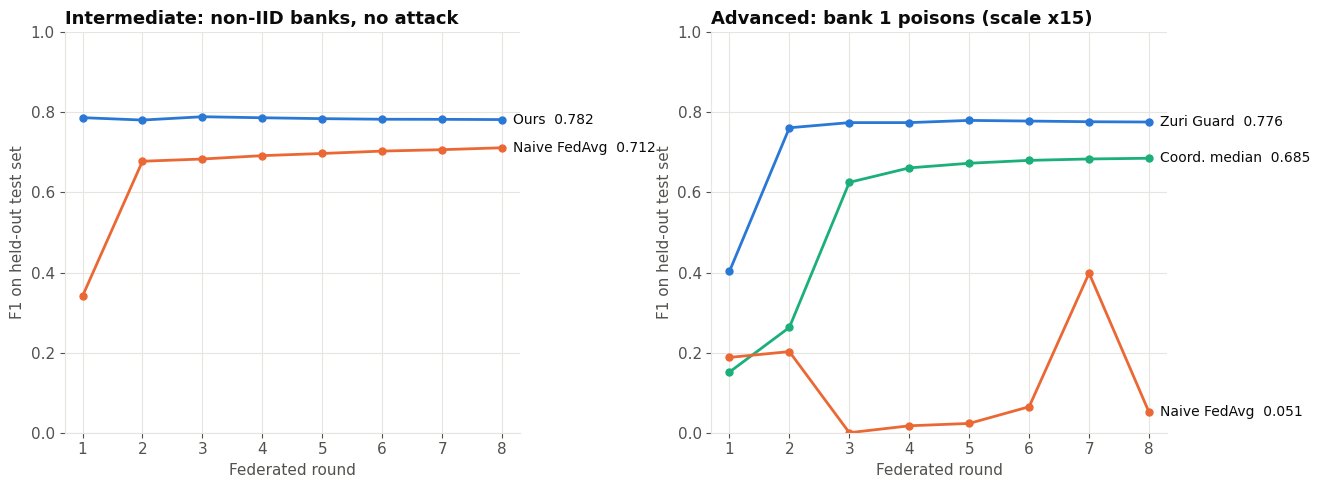

In [17]:
# Palette: ours is blue, naive FedAvg orange, the median baseline aqua, references in neutral grey
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "axes.edgecolor": GRID,
                     "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": GRID, "grid.linewidth": 0.8, "figure.facecolor": "white"})

def f1_curve(history):
    return [h["f1"] for h in history]

def line_panel(ax, series, title):
    for label, hist, color, style in series:
        ys = f1_curve(hist)
        xs = range(1, len(ys) + 1)
        ax.plot(xs, ys, color=color, lw=2, ls=style, marker="o", ms=5)
        ax.annotate(f"{label}  {ys[-1]:.3f}", (len(ys), ys[-1]), xytext=(8, 0),
                    textcoords="offset points", va="center", color=INK, fontsize=10)
    ax.set_title(title, loc="left", color=INK, fontsize=13, fontweight="bold")
    ax.set_xlabel("Federated round"); ax.set_ylabel("F1 on held-out test set")
    ax.set_ylim(0, 1); ax.set_xlim(0.7, 8.3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
line_panel(axes[0], [("Ours", custom_history, BLUE, "-"),
                     ("Naive FedAvg", noniid_history, ORANGE, "-")],
           "Intermediate: non-IID banks, no attack")
line_panel(axes[1], [("Zuri Guard", my_defense_history, BLUE, "-"),
                     ("Coord. median", defended_history, AQUA, "-"),
                     ("Naive FedAvg", attacked_history, ORANGE, "-")],
           "Advanced: bank 1 poisons (scale x15)")
for ax in axes: ax.margins(x=0)
plt.subplots_adjust(right=0.86, wspace=0.42)
fig.savefig("figures/f1_over_rounds.png", dpi=160, bbox_inches="tight")
plt.show()

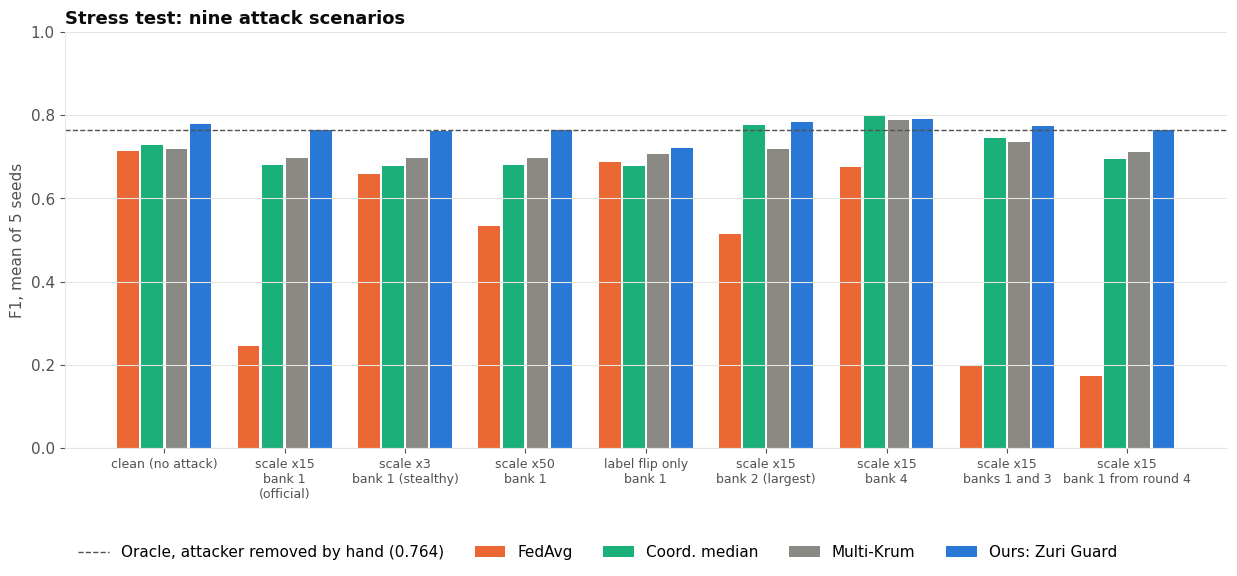

In [18]:
# Stress test as grouped bars (5-seed mean F1), one group per scenario
show = ["FedAvg", "Coord. median", "Multi-Krum", "Ours: Zuri Guard"]
colors = [ORANGE, AQUA, GREY, BLUE]
labels = [s.replace(" (official)", "\n(official)").replace(", bank", "\nbank").replace(", banks", "\nbanks") for s in stress_df.index]
x = np.arange(len(stress_df)); width = 0.2
fig, ax = plt.subplots(figsize=(15, 5.4))
for i, (name, c) in enumerate(zip(show, colors)):
    ax.bar(x + (i - 1.5) * width, stress_df[name].values, width - 0.02, color=c, label=name)
ax.axhline(oracle["f1_mean"], color=INK2, ls="--", lw=1, label=f"Oracle, attacker removed by hand ({oracle['f1_mean']:.3f})")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1); ax.set_ylabel("F1, mean of 5 seeds")
ax.set_title("Stress test: nine attack scenarios", loc="left", color=INK, fontsize=13, fontweight="bold")
ax.legend(ncol=5, frameon=False, loc="upper left", bbox_to_anchor=(0, -0.2))
ax.grid(axis="x", visible=False)
fig.savefig("figures/stress_test.png", dpi=160, bbox_inches="tight")
plt.show()

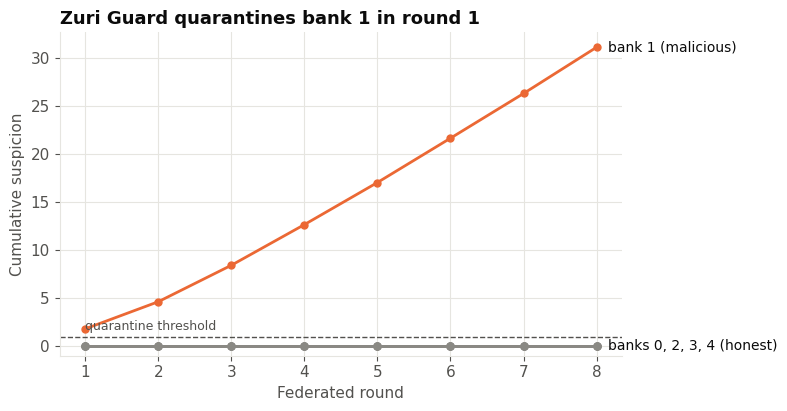

In [19]:
# Detection timeline for the official scenario: suspicion per bank each round
susp = np.array([e["suspicion"] for e in guard_log])
fig, ax = plt.subplots(figsize=(9, 4.2))
rounds_axis = range(1, len(susp) + 1)
for b in range(susp.shape[1]):
    color = ORANGE if b == 1 else GREY
    ax.plot(rounds_axis, susp[:, b], color=color, lw=2, marker="o", ms=5)
honest_banks = [b for b in range(susp.shape[1]) if b != 1]
ax.annotate("bank 1 (malicious)", (len(susp), susp[-1, 1]), xytext=(8, 0), textcoords="offset points",
            va="center", fontsize=10, color=INK)
ax.annotate("banks " + ", ".join(map(str, honest_banks)) + " (honest)", (len(susp), susp[-1, honest_banks].max()),
            xytext=(8, 0), textcoords="offset points", va="center", fontsize=10, color=INK)
ax.axhline(1.0, color=INK2, ls="--", lw=1)
ax.annotate("quarantine threshold", (1, 1.0), xytext=(0, 5), textcoords="offset points", color=INK2, fontsize=9)
ax.set_ylim(bottom=-1)
ax.set_xlabel("Federated round"); ax.set_ylabel("Cumulative suspicion")
ax.set_title("Zuri Guard quarantines bank 1 in round 1", loc="left", color=INK, fontsize=13, fontweight="bold")
plt.subplots_adjust(right=0.75)
fig.savefig("figures/detection_timeline.png", dpi=160, bbox_inches="tight")
plt.show()

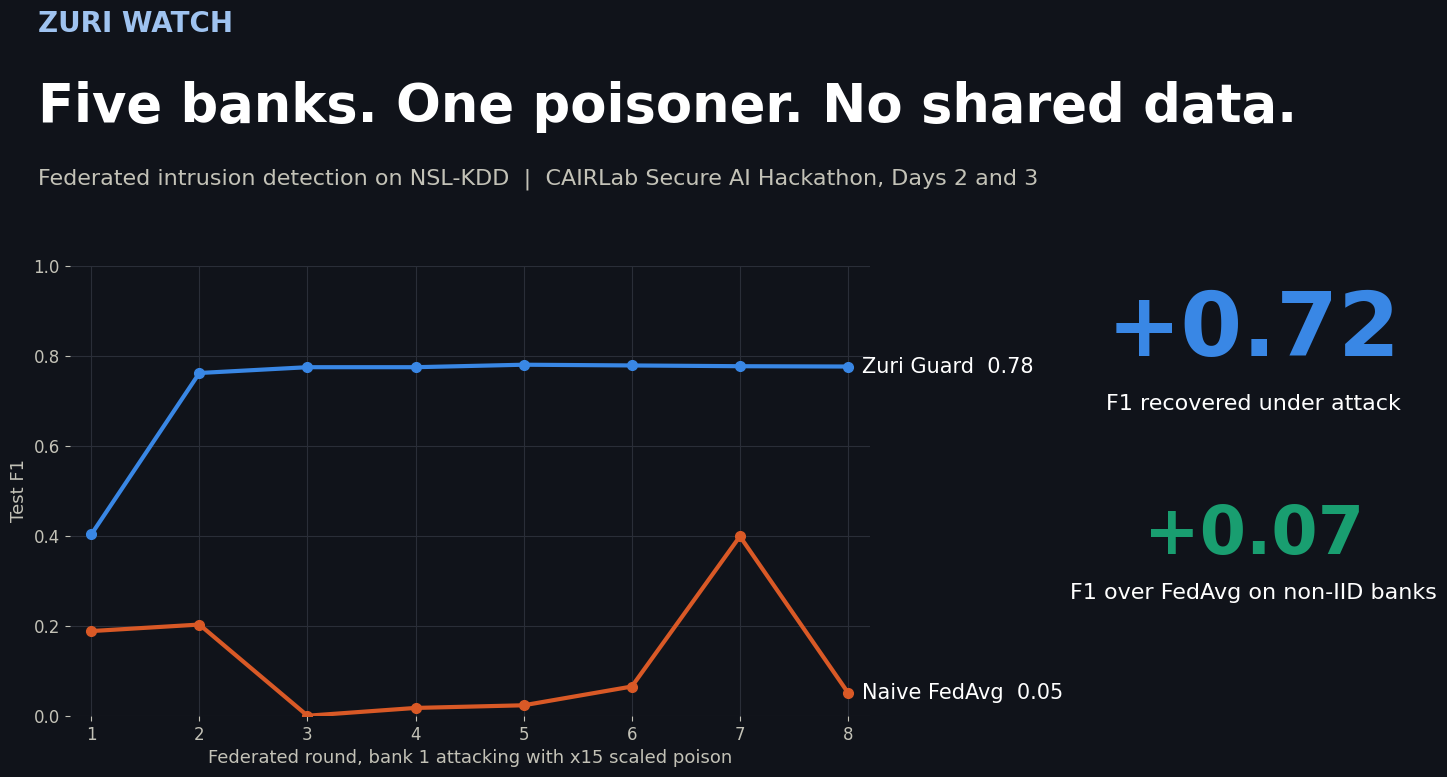

In [20]:
# Cover image for the Kaggle media gallery (16:9)
fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor("#10131a")
fig.text(0.05, 0.88, "ZURI WATCH", color="#9fc3f0", fontsize=20, fontweight="bold")
fig.text(0.05, 0.78, "Five banks. One poisoner. No shared data.", color="white", fontsize=38, fontweight="bold")
fig.text(0.05, 0.71, "Federated intrusion detection on NSL-KDD  |  CAIRLab Secure AI Hackathon, Days 2 and 3",
         color="#c3c2b7", fontsize=16)
ax = fig.add_axes([0.07, 0.12, 0.5, 0.5]); ax.set_facecolor("#10131a")
for label, hist, color in [("Zuri Guard", my_defense_history, "#3987e5"),
                           ("Naive FedAvg", attacked_history, "#d95926")]:
    ys = f1_curve(hist)
    ax.plot(range(1, len(ys) + 1), ys, color=color, lw=3, marker="o", ms=7)
    ax.annotate(f"{label}  {ys[-1]:.2f}", (len(ys), ys[-1]), xytext=(10, 0), textcoords="offset points",
                va="center", color="white", fontsize=15)
ax.set_ylim(0, 1); ax.set_xlim(0.8, 8.2)
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(colors="#c3c2b7", labelsize=12); ax.grid(color="#2a2e38")
ax.set_xlabel("Federated round, bank 1 attacking with x15 scaled poison", color="#c3c2b7", fontsize=13)
ax.set_ylabel("Test F1", color="#c3c2b7", fontsize=13)
gain_adv = my_defense_history[-1]["f1"] - attacked_history[-1]["f1"]
gain_int = custom_history[-1]["f1"] - noniid_history[-1]["f1"]
fig.text(0.81, 0.52, f"+{gain_adv:.2f}", color="#3987e5", fontsize=64, fontweight="bold", ha="center")
fig.text(0.81, 0.46, "F1 recovered under attack", color="white", fontsize=16, ha="center")
fig.text(0.81, 0.30, f"+{gain_int:.2f}", color="#199e70", fontsize=48, fontweight="bold", ha="center")
fig.text(0.81, 0.25, "F1 over FedAvg on non-IID banks", color="white", fontsize=16, ha="center")
fig.savefig("figures/cover.png", dpi=120, facecolor=fig.get_facecolor())
plt.show()

In [21]:
# Every number quoted in the writeup, in one file
results = {
    "seed_for_headline_runs": SEED,
    "intermediate": {
        "iid_reference_fedavg_f1": baseline_history[-1]["f1"],
        "before_naive_fedavg_noniid": noniid_history[-1],
        "after_ours_noniid": custom_history[-1],
        "improvement_f1": round(custom_history[-1]["f1"] - noniid_history[-1]["f1"], 4),
        "five_seed_ablation": ablation,
        "recall_by_family": family_df.to_dict(),
    },
    "advanced": {
        "before_naive_fedavg_under_attack": attacked_history[-1],
        "median_baseline_under_attack": defended_history[-1],
        "after_zuri_guard_under_attack": my_defense_history[-1],
        "f1_recovered": round(my_defense_history[-1]["f1"] - attacked_history[-1]["f1"], 4),
        "detection_log_official_run": guard_log,
        "stress_test_5_seed_mean_f1": stress,
        "oracle_attacker_removed_f1_mean": oracle["f1_mean"],
        "detection_summary": detect_df.groupby("scenario")[["true_positives", "false_positives", "missed"]].sum().to_dict(),
    },
}
with open("results.json", "w") as f:
    json.dump(results, f, indent=2, default=float)
print("Intermediate  before", noniid_history[-1]["f1"], " after", custom_history[-1]["f1"],
      " gain", results["intermediate"]["improvement_f1"])
print("Advanced      before", attacked_history[-1]["f1"], " after", my_defense_history[-1]["f1"],
      " recovered", results["advanced"]["f1_recovered"])

Intermediate  before 0.7117  after 0.7821  gain 0.0704
Advanced      before 0.0511  after 0.776  recovered 0.7249


---
## 8. Submission (rubric-graded, no Kaggle leaderboard)

Run this to export your final model. Pick whichever result (intermediate aggregation or
advanced defense) you want judged — set `TRACK` and `FINAL_MODEL` accordingly.

**Input contract:** your exported model's `forward(x)` must accept the standard 41-column
preprocessed feature tensor exactly as produced in Section 1 (`FEATURE_COLS`, same order,
same scaling). If you did feature engineering, build it as extra layers *inside* your model
rather than as a separate preprocessing step.

In [22]:
TEAM_NAME = "Zuri Watch"
TRACK = "advanced"  # "intermediate" or "advanced"
FINAL_MODEL = my_defense_model  # Zuri Guard, trained with bank 1 attacking (scale x15)

final_metrics = evaluate(FINAL_MODEL)

FINAL_MODEL.eval()
scripted = torch.jit.script(FINAL_MODEL)
scripted.save("model_scripted.pt")

submission = {
    "team_name": TEAM_NAME,
    "track": TRACK,
    "self_reported_metrics": final_metrics,
    "model_file": "model_scripted.pt",
    "n_input_features": N_FEATURES,
}
with open("submission.json", "w") as f:
    json.dump(submission, f, indent=2)

print(json.dumps(submission, indent=2))
print("\nInclude model_scripted.pt and submission.json in your GitHub repo (your Writeup's Project Link).")

# quick self check: reload the exported file and confirm it scores the same
reloaded = torch.jit.load("model_scripted.pt")
with torch.no_grad():
    p = (torch.sigmoid(reloaded(X_test)) > 0.5).float()
assert round(f1_score(y_test, p), 4) == final_metrics["f1"]
print("Reloaded model_scripted.pt reproduces F1", final_metrics["f1"])

{
  "team_name": "Zuri Watch",
  "track": "advanced",
  "self_reported_metrics": {
    "precision": 0.925,
    "recall": 0.6684,
    "f1": 0.776
  },
  "model_file": "model_scripted.pt",
  "n_input_features": 41
}

Include model_scripted.pt and submission.json in your GitHub repo (your Writeup's Project Link).
Reloaded model_scripted.pt reproduces F1 0.776


/usr/local/lib/python3.11/dist-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


### What to hand in
1. Your Kaggle Writeup — include the before/after F1 comparison for whichever track(s) you
   attempted, this is your primary evidence for the Automated Detection Score.
2. Your GitHub repo (Project Link) containing `model_scripted.pt`, `submission.json`, and
   this notebook, fully run.
3. Cover image, video (≤3 min), all per the Submission Requirements.
4. Be ready to demo live on Day 7.